## Homework 4: Unsupervised Learning

### Exercise 3: Image Compression with SVD

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

In [17]:
def load_cameraman_512():
    X = data.camera().astype(float)
    return X

def svd_decompose(X):
    # full_matrices=False gives compact SVD:
    # X = U @ diag(S) @ Vt, where U is (m x r), S is (r,), Vt is (r x n)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    return U, S, Vt

def rank_k_approx(U, S, Vt, k):
    # X_k = U_k @ diag(S_k) @ Vt_k
    Uk = U[:, :k]
    Sk = S[:k]
    Vtk = Vt[:k, :]
    return Uk @ (Sk[:, None] * Vtk)

def reconstruction_error_fro(X, Xk):
    # Frobenius norm error ||X - Xk||_F
    return np.linalg.norm(X - Xk, ord="fro")

def compression_factor(m, n, k):
    return 1.0 - (k * (m + n + 1)) / (m * n)

In [18]:
def execute_process(k_list=(5, 20, 50, 100, 200)):
    X = load_cameraman_512()
    m, n = X.shape

    U, S, Vt = svd_decompose(X)

    Xks = []
    errs = []
    comps = []

    for k in k_list:
        Xk = rank_k_approx(U, S, Vt, k)
        Xks.append(Xk)

        err = reconstruction_error_fro(X, Xk)
        errs.append(err)

        ck = compression_factor(m, n, k)
        comps.append(ck)


    # Show original + reconstructed images
    # Layout: 2 rows x 3 cols = original and 5 reconstructions
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    axs = axs.ravel()

    axs[0].imshow(X, cmap="gray", vmin=0, vmax=255)
    axs[0].set_title("Original (512x512)")
    axs[0].axis("off")

    for i, k in enumerate(k_list, start=1):
        axs[i].imshow(Xks[i - 1], cmap="gray", vmin=0, vmax=255)
        axs[i].set_title(f"Image with k={k}")
        axs[i].axis("off")

    plt.suptitle("Image Compression with SVD (Cameraman)", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Plot reconstruction error vs k
    plt.figure(figsize=(7, 4))
    plt.plot(k_list, errs, marker="o")
    plt.title("Reconstruction Error vs k")
    plt.xlabel("k (rank)")
    plt.ylabel(r"$\|X - X_k\|_F$")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Plot compression factor vs k
    plt.figure(figsize=(7, 4))
    plt.plot(k_list, comps, marker="o")
    plt.title("Compression Factor vs k")
    plt.xlabel("k (rank)")
    plt.ylabel(r"$c_k = 1 - \frac{k(m+n+1)}{mn}$")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"Image size: m={m}, n={n}")
    print("k\t||X - Xk||_F\tcompression c_k")
    for k, e, c in zip(k_list, errs, comps):
        print(f"{k}\t{e:.4f}\t\t{c:.4f}")

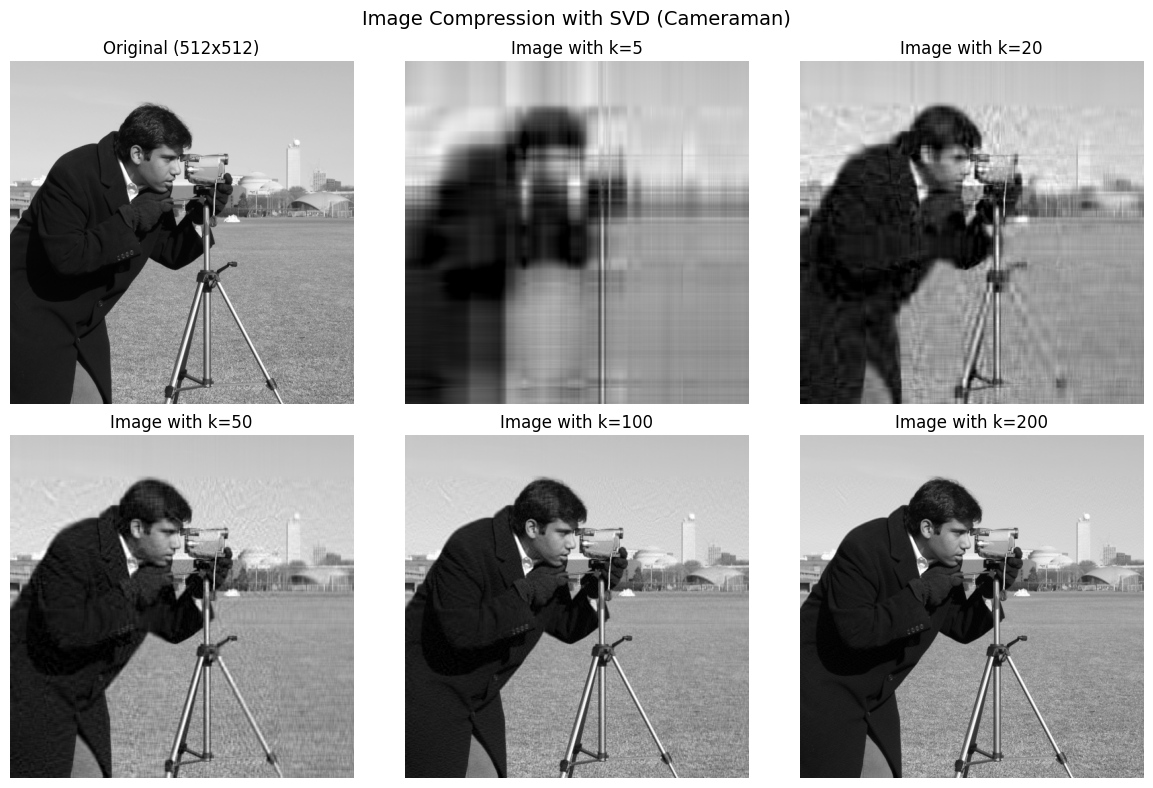

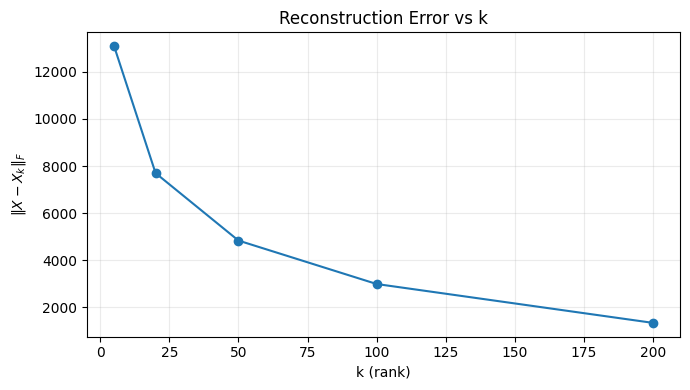

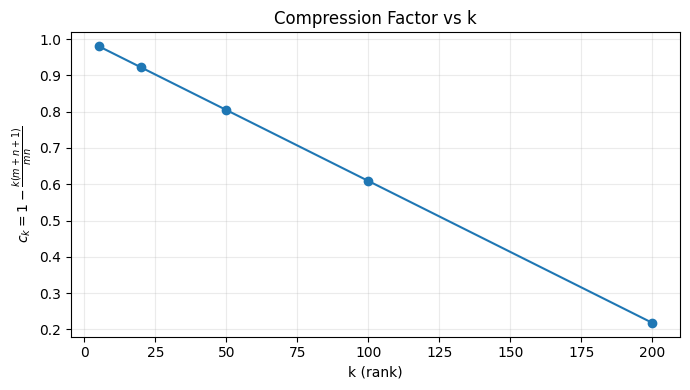

Image size: m=512, n=512
k	||X - Xk||_F	compression c_k
5	13086.8683		0.9804
20	7699.9091		0.9218
50	4836.0689		0.8045
100	2992.1444		0.6090
200	1342.3582		0.2180


In [19]:
execute_process(k_list=(5, 20, 50, 100, 200))